# Permutation Test H - Node metrics vs Regional TSPO in AAL

## Test H.4 - Fixed group size, spatial null of subject-wise fMRI graph metrics & regional TSPO 

This notebook performs test H.2 for the dataset using the AAL89 parcellation. It can be used for any other dataset, simply change the directories and variables accordingly (see attached comments).

Importing data.

In [ ]:
import numpy as np
import networkx as nx
import scipy.special as ss
from networkx import tree
import os
import glob
def adj_matrix_connected(corr_matrix,sparsity_value):
    """given the correlation matrix and the expected sparsity coefficient it can 
    happen that the corresponding thresholded matrix results in a disconnected graph
    here we force the graph to be fully connected by the computation of the minimum
    spanning tree and adding the required edges in order to have a unique connected component 
    """
    if sparsity_value == 1.0:
        adj_matrix=np.ones(corr_matrix.shape)
        np.fill_diagonal(adj_matrix,0)
        return adj_matrix
        
    
    corr_matrix =abs(corr_matrix)

    max_num_edges = ss.comb(corr_matrix.shape[0],2)
    num_edges = int(max_num_edges*sparsity_value)
    
    num_regions=corr_matrix.shape[0]
    #total number of regions in the graph
        
    totalgraph=nx.from_numpy_array(1-abs(corr_matrix))
    #extraction of a complete graph having has weight 1-abs(correlation)
    #we need to take 1-abs since the mst is taking the minimum weight graph and we want the most correlated edges to be there
    
    MST=nx.to_numpy_array(tree.minimum_spanning_tree(totalgraph).to_undirected())
    MST_adj_mat=MST
    MST_adj_mat[MST>0]==1
    MST_adj_mat=np.triu(MST_adj_mat) #put zeros in the inferior triangular matrix
    
    #put zeros in the diagonal of the corr matrix
    for i in range(num_regions):
        corr_matrix[i,i]=0
    
    values_corr=abs(np.triu(corr_matrix))
    
    cor_wo_MST=values_corr[np.triu(MST_adj_mat)==0]
    #we do not consider the correlation values which do not involve edges that are already in the MST
    
    values=list(cor_wo_MST.flatten())
    values.sort(reverse=True)
    
    #we select the maximum value of correlation to have the expected num of edges - num of edges in the mst (num regions-1)
    value_thresh=values[num_edges-(num_regions-1)-1] #-1 index start at 0
    
    adj_matrix=np.zeros(corr_matrix.shape) 
    
    #we put an edge if the value of correlation is higher than the found threshold or if the edges is required by the mst
    adj_matrix[values_corr>=value_thresh]=1
    adj_matrix[MST_adj_mat!=0]=1
    
    adj_matrix=np.triu(adj_matrix)+np.transpose(np.triu(adj_matrix)) #simmetry of the adj matrix
    
    return adj_matrix

def single_nodal_statistic(G, statistics=["d"],precision=2):
    
    """ 
    Input: a graph, a set of statistics. 

    Computes the indicated nodal statistic of a given graph for the given nodal statistic

    Output: a dictionary, for each nodal statistic we get the values for the given graph
    
    """
    nodal_stats={}
    error_case = {"0":set(G.nodes())}
    if "d" in statistics:
        
        try:
            nodal_stats["d"] = dict(G.degree())
        except:
            nodal_stats["d"] = error_case
            
    return nodal_stats

In [ ]:

controls_aal = [
    "01FO", "02LE", "03GA", "04GM", "05IM", "07NA", "08CP", "09DM", "11GL", "12LJ",
    "13AE", "14PM", "15GT", "16DT", "17LY", "19DG", "20CP", "21LJ", "22DD", "23BA"
]

anoxic_aal = [ # Effective Anoxic patients
    "01JF", "02PD", "06BM", "07TA", "14RC"
]
traumatic_aal = [  # Effective Traumatic patients  - Patient 08PE must be excluded from studies using AICHA 
    "03DB", "08PE", "11FC", "13TL", "16FF", "22BT", "23GC", "24ZX", "26AC"
]

matrices_path = "/Data/Correlation_Matrices/AAL" # Simply change the last path to import other atlases, e.g. AICHA
control_path = os.path.join(matrices_path, "Controls")
anoxic_path = os.path.join(matrices_path, "Anoxic")
traumatic_path = os.path.join(matrices_path, "Traumatic")

# Final filter before importing - matching IDs from lists to files to exclude non-effective subjects

control_subjects = sorted(
    s for s in glob.glob(os.path.join(control_path, "*"))
    if os.path.basename(s).split(".")[0] in controls_aal
)

anoxic_subjects = sorted(
    s for s in glob.glob(os.path.join(anoxic_path, "*"))
    if os.path.basename(s).split(".")[0] in anoxic_aal
)

traumatic_subjects = sorted(
    s for s in glob.glob(os.path.join(traumatic_path, "*"))
    if os.path.basename(s).split(".")[0] in traumatic_aal
)

# Importing correlations - Keys are IDs, values are matrices

control_correlations = {}
for sub in control_subjects:
    control_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)


traumatic_correlations = {}
for sub in traumatic_subjects:
    traumatic_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)

anoxic_correlations = {}
for sub in anoxic_subjects:
    anoxic_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)

print(f"Controls: {len(control_correlations.keys())}, Anoxic: {len(anoxic_correlations.keys())}, Traumatic: {len(traumatic_correlations.keys())}")

# fMRI graphs
costs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
controls_fmri_graphs = {cost:{sub: None for sub in control_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in control_correlations.keys(): # Keys are IDs, values are nx.Graph objects
        controls_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(control_correlations[sub], cost))

anoxic_fmri_graphs = {cost:{sub: None for sub in anoxic_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in anoxic_correlations.keys():
        anoxic_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(anoxic_correlations[sub], cost))

traumatic_fmri_graphs = {cost:{sub: None for sub in traumatic_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in traumatic_correlations.keys():
        traumatic_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(traumatic_correlations[sub], cost))

# We can merge the coma dataset in one dictionary

coma_fmri_graphs = {cost: {} for cost in costs}

for cost in costs:
    coma_fmri_graphs[cost] = {**anoxic_fmri_graphs[cost], **traumatic_fmri_graphs[cost]}


Controls: 20, Anoxic: 5, Traumatic: 9


Regional TSPO

In [ ]:
import pandas as pd
tspo_path = "/Data/Regional_TSPO/AAL" # Idem, change the last path element to import another atlas
control_tspo_data = {}

control_tspo_files = glob.glob(os.path.join(tspo_path, "Controls", "*"))
for file in control_tspo_files:
    id = os.path.splitext(os.path.basename(file))[0] 
    control_tspo_data[id] = pd.read_csv(file)

anoxic_tspo_data = {}

anoxic_tspo_files = glob.glob(os.path.join(tspo_path, "Anoxic", "*"))
for file in anoxic_tspo_files:
    id = os.path.splitext(os.path.basename(file))[0] 
    if id in anoxic_aal:
        anoxic_tspo_data[id] = pd.read_csv(file)

traumatic_tspo_data = {}

traumatic_tspo_files = glob.glob(os.path.join(tspo_path, "Traumatic", "*"))
for file in traumatic_tspo_files:
    id = os.path.splitext(os.path.basename(file))[0]
    if id in traumatic_aal:
        traumatic_tspo_data[id] = pd.read_csv(file)

In [4]:
coma_tspo_data = {**anoxic_tspo_data, **traumatic_tspo_data}

Mean of regional tspo 

Mean of regional TSPO

Number of elements in `mode_controls` and other arrays depends on the number of nodes per atlas:
* AAL - 89
* Schaefer119 - 119
* Schaefer223 - 223
* AICHA - 391

In [5]:
import numpy as np 

mode_controls = np.zeros((len(control_tspo_data.keys()), 89))
for i, px in enumerate(control_tspo_data.keys()):
    mode_controls[i] = control_tspo_data[px]['Mode'] # Mode is interpreted as regional TSPO
m_mode_control = np.mean(mode_controls, axis=0)

mode_anoxic = np.zeros((len(anoxic_tspo_data.keys()), 89))
for i, px in enumerate(anoxic_tspo_data.keys()):
    mode_anoxic[i] = anoxic_tspo_data[px]['Mode']

m_mode_anoxic = np.mean(mode_anoxic, axis=0)

mode_traumatic = np.zeros((len(traumatic_tspo_data.keys()), 89))
for i, px in enumerate(traumatic_tspo_data.keys()):
    mode_traumatic[i] = traumatic_tspo_data[px]['Mode']

m_mode_traumatic = np.mean(mode_traumatic, axis=0)

In [6]:
# Create list of subject IDs in the same order as used for nodal metrics
#anoxic_subjects = list(anoxic_mapped_ids.keys())
#traumatic_subjects = list(traumatic_mapped_ids.keys())

# Preallocate array for combined TSPO Mode data
mode_coma = np.zeros((len(anoxic_aal) + len(traumatic_aal), 89))

# Fill in TSPO Mode data for anoxic subjects
for i, px in enumerate(anoxic_aal):
    mode_coma[i] = anoxic_tspo_data[px]['Mode']

# Fill in TSPO Mode data for traumatic subjects
for i, px in enumerate(traumatic_aal):
    mode_coma[len(anoxic_subjects) + i] = traumatic_tspo_data[px]['Mode']

# Compute mean across all subjects
m_mode_coma = np.mean(mode_coma, axis=0)


Mean node metrics at group level - Mean degree for node 1, etc. 

In [ ]:
metrics_list = ['d']
nodal_metrics_controls = {
    cost: {px: {} for px in controls_fmri_graphs[0.1].keys()} for cost in costs
}
for cost in costs:
    for px in controls_fmri_graphs[0.1].keys():
        graph = controls_fmri_graphs[cost][px]
        nodal_metrics_controls[cost][px] = single_nodal_statistic(graph, metrics_list)

mean_metrics_control = {
    cost: {metric: None for metric in metrics_list} for cost in costs
}

for cost in costs:
    for metric in metrics_list:
        mat =  np.zeros((len(controls_fmri_graphs[0.1].keys()), 89))
        for i, px in enumerate(controls_fmri_graphs[0.1].keys()):
            mat[i] = list(nodal_metrics_controls[cost][px][metric].values())
        mean_metrics_control[cost][metric] = np.mean(mat, axis=0)



In [8]:

nodal_metrics_anoxic = {
    cost: {px: {} for px in anoxic_fmri_graphs[0.1].keys()} for cost in costs
}
for cost in costs:
    for px in anoxic_fmri_graphs[0.1].keys():
        graph = anoxic_fmri_graphs[cost][px]
        nodal_metrics_anoxic[cost][px] = single_nodal_statistic(graph, metrics_list)

mean_metrics_anoxic = {
    cost: {metric: None for metric in metrics_list} for cost in costs
}

for cost in costs:
    for metric in metrics_list:
        mat =  np.zeros((len(anoxic_fmri_graphs[0.1].keys()), 89))
        for i, px in enumerate(anoxic_fmri_graphs[0.1].keys()):
            mat[i] = list(nodal_metrics_anoxic[cost][px][metric].values())
        mean_metrics_anoxic[cost][metric] = np.mean(mat, axis=0)



In [9]:

nodal_metrics_traumatic = {
    cost: {px: {} for px in traumatic_fmri_graphs[0.1].keys()} for cost in costs
}
for cost in costs:
    for px in traumatic_fmri_graphs[0.1].keys():
        graph = traumatic_fmri_graphs[cost][px]
        nodal_metrics_traumatic[cost][px] = single_nodal_statistic(graph, metrics_list)

mean_metrics_traumatic = {
    cost: {metric: None for metric in metrics_list} for cost in costs
}

for cost in costs:
    for metric in metrics_list:
        mat =  np.zeros((len(traumatic_fmri_graphs[0.1].keys()), 89))
        for i, px in enumerate(traumatic_fmri_graphs[0.1].keys()):
            mat[i] = list(nodal_metrics_traumatic[cost][px][metric].values())
        mean_metrics_traumatic[cost][metric] = np.mean(mat, axis=0)



In [10]:
mean_metrics_coma = {
    cost: {metric: None for metric in metrics_list} for cost in costs
}

for cost in costs:
    for metric in metrics_list:
        # Create matrices for both groups
        mat_anoxic = np.zeros((len(anoxic_correlations), 89))
        for i, px in enumerate(anoxic_correlations):
            mat_anoxic[i] = list(nodal_metrics_anoxic[cost][px][metric].values())

        mat_traumatic = np.zeros((len(traumatic_correlations), 89))
        for i, px in enumerate(traumatic_correlations):
            mat_traumatic[i] = list(nodal_metrics_traumatic[cost][px][metric].values())

        # Combine and compute mean
        coma_mat = np.vstack((mat_anoxic, mat_traumatic))
        mean_metrics_coma[cost][metric] = np.mean(coma_mat, axis=0)


In [11]:
mean_node_metrics_fmri = {
    "Controls": mean_metrics_control,
    "Coma": mean_metrics_coma
}

mean_tspo_metrics = {
    "Controls": m_mode_control,
    "Coma": m_mode_coma
}

In [13]:
coma_aal = anoxic_aal + traumatic_aal 

In [14]:
nodal_metrics_coma = {}

for cost in costs:
    nodal_metrics_coma[cost] = {**nodal_metrics_anoxic[cost], **nodal_metrics_traumatic[cost]}

# Permutation test

_“Does the observed fMRI–TSPO association depend on the spatial organization of fMRI metrics & TSPO?”_

_"“Is the observed slope larger than what would arise when neither modality has meaningful spatial structure, but their marginal distributions are preserved?”"_

In [ ]:
from sklearn.linear_model import LinearRegression

# Extract regional fmri vectors once

def extract_regional_fmri(nodal_metrics, subjects, cost, metric):
    """
    Returns dict: subject -> (n_nodes,) array
    """
    return {
        sub: np.array(list(nodal_metrics[cost][sub][metric].values()))
        for sub in subjects
    }

# Extract regional tspo vectors

def extract_regional_tspo(tspo_data, subjects):
    """
    Returns dict: subject -> (n_nodes,) array
    """
    return {
        sub: tspo_data[sub]["Mode"].to_numpy()
        for sub in subjects
    }


# Subject-wise spatial permutation

def spatial_shuffle_subjectwise(regional_fmri):
    """
    Permute node values independently for each subject
    """
    return {
        sub: np.random.permutation(vec)
        for sub, vec in regional_fmri.items()
    }


def group_mean_map(regional_fmri, subjects, n_nodes):
    mat = np.zeros((len(subjects), n_nodes))
    for i, sub in enumerate(subjects):
        mat[i] = regional_fmri[sub]
    return mat.mean(axis=0)


#n_iterations = 1000
n_iterations = 10000
xcosts = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
groups = ["Controls", "Coma"]
n_nodes = 89 # Change depending on the atlas used

subjects = {
    "Controls": controls_aal,
    "Coma": coma_aal
}

nodal_data = {
    "Controls": nodal_metrics_controls,
    "Coma": nodal_metrics_coma
}

tspo_data = {
    "Controls": control_tspo_data,
    "Coma": coma_tspo_data
}

# storage
xcoeffs = {
    g: {cost: {m: [] for m in metrics_list} for cost in xcosts}
    for g in groups
}

for it in range(n_iterations):

    for cost in xcosts:
        for metric in metrics_list:

            # --- extract real subject-wise data ---
            regional_fmri = {
                g: extract_regional_fmri(
                    nodal_data[g],
                    subjects[g],
                    cost,
                    metric
                )
                for g in groups
            }

            regional_tspo = {
                g: extract_regional_tspo(
                    tspo_data[g],
                    subjects[g]
                )
                for g in groups
            }

            # --- spatial shuffle (subject-wise) ---
            xregional_fmri = {
                g: spatial_shuffle_subjectwise(regional_fmri[g])
                for g in groups
            }

            xregional_tspo = {
                g: spatial_shuffle_subjectwise(regional_tspo[g])
                for g in groups
            }

            # --- group means ---
            xmean_fmri = {
                g: group_mean_map(
                    xregional_fmri[g],
                    subjects[g],
                    n_nodes
                )
                for g in groups
            }

            xmean_tspo = {
                g: group_mean_map(
                    xregional_tspo[g],
                    subjects[g],
                    n_nodes
                )
                for g in groups
            }

            # --- regression ---
            for g in groups:
                x = xmean_fmri[g].reshape(-1, 1)
                y = xmean_tspo[g]

                model = LinearRegression().fit(x, y)
                xcoeffs[g][cost][metric].append(model.coef_[0])



In [22]:
real_slopes = {group: {
    cost: {
        metric: None for metric in metrics_list
    } for cost in xcosts
} for group in groups}

for group in groups:
    for cost in xcosts:
        for metric in metrics_list:
            x = mean_node_metrics_fmri[group][cost][metric].reshape(-1, 1)
            y = mean_tspo_metrics[group]

            # Linear regression
            model = LinearRegression()
            model.fit(x, y)
            real_slopes[group][cost][metric] = model.coef_[0]

In [23]:
def cohens_d(original_value, bootstrap_distribution):
    mean_boot = np.mean(bootstrap_distribution)
    std_boot = np.std(bootstrap_distribution, ddof=1)  # Sample std dev
    return (original_value - mean_boot) / std_boot

In [24]:
# Results 10k
from statsmodels.stats.multitest import fdrcorrection

# define once, outside the loops
metric = 'd' 
groups = ['Controls', 'Coma']
xcost = 0.1  # only one xcost now
p_values_uncorrected = [] # to store them

for group in groups:

    # get the bootstrap slopes and the real slope
    boot_slopes = xcoeffs[group][xcost][metric]
    real_slope  = real_slopes[group][xcost][metric]

    # Percentile of the original slope in the bootstrapped distribution
    percentile = np.mean(boot_slopes < real_slope) * 100

    # One-tailed and two-tailed p-values
    p_value_one_tailed = 1 - (percentile / 100)
    p_value_two_tailed = 2 * min(p_value_one_tailed, 1 - p_value_one_tailed)
    p_values_uncorrected.append(p_value_two_tailed) # we store each time


    # Cohen's D
    cohens_d_value = cohens_d(real_slope, boot_slopes)

    # Confidence intervals
    ci_low = np.percentile(boot_slopes, 2.5)
    ci_high = np.percentile(boot_slopes, 97.5)

    # Apply FDR correction (Benjamini-Hochberg)
    rejected, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.05)

# Print results
for group, raw_p, fdr_p, reject in zip(groups, p_values_uncorrected, p_values_fdr, rejected):
    print(group)
    print(f"Observed slope: {real_slope}")
    print(f"Effect size: {cohens_d_value}")
    print(f"CI: {ci_low}, {ci_high}")
    print(f"raw p = {raw_p:3f}, FDR-corrected p = {fdr_p:3f}, significant: {reject} \n")



Controls
Observed slope: -0.004870998910081459
Effect size: -1.0900306951432774
CI: -0.00875980250862252, 0.00877008432339058
raw p = 0.681200, FDR-corrected p = 0.681200, significant: False 

Coma
Observed slope: -0.004870998910081459
Effect size: -1.0900306951432774
CI: -0.00875980250862252, 0.00877008432339058
raw p = 0.276600, FDR-corrected p = 0.553200, significant: False 



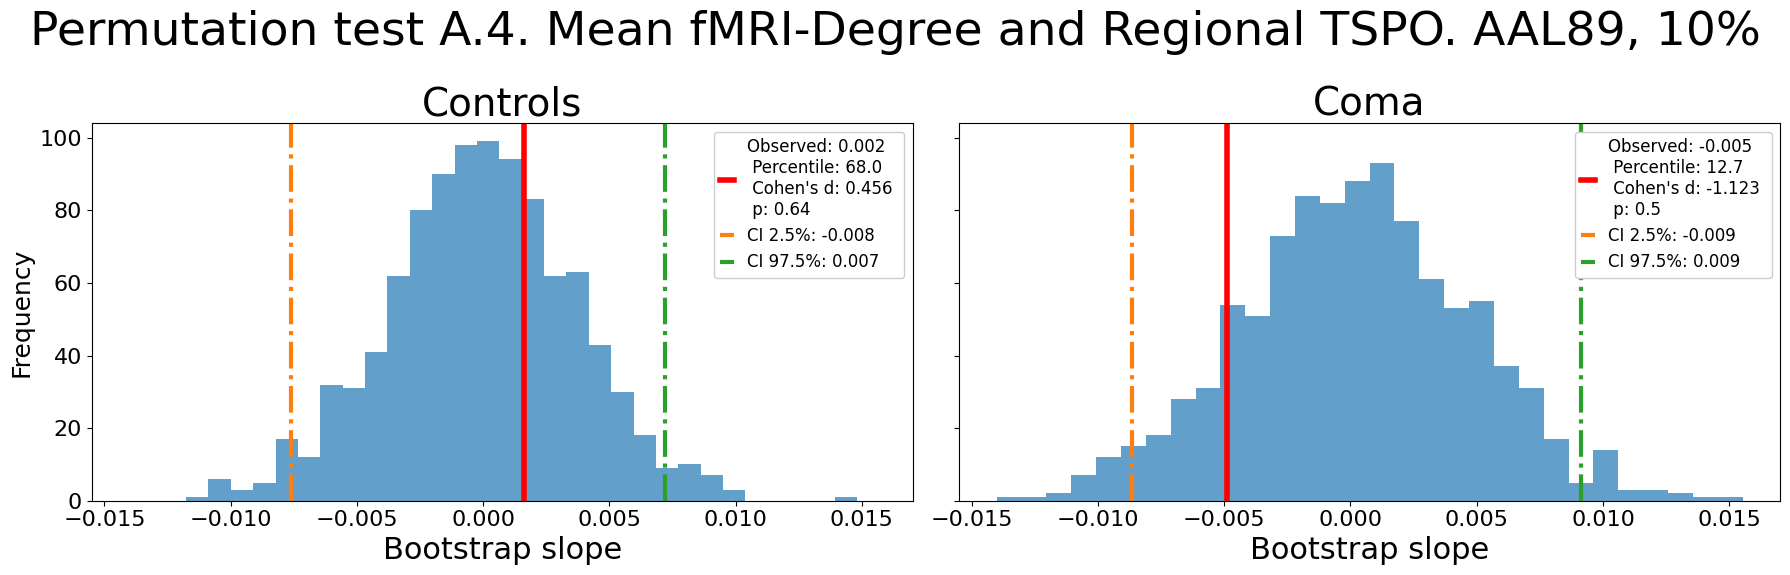

In [ ]:
import matplotlib.pyplot as plt

metric = 'd'  
groups = ['Controls', 'Coma']
xcost = 0.1 
p_values_uncorrected = [] # to store them
p_print = [0.64, 0.5]
# make subplots (1 row, len(groups) columns)
fig, axes = plt.subplots(nrows=1, ncols=len(groups),
                         figsize=(18, 6), sharex=True, sharey=True)

# if there's only one row, axes is a 1D array
for j, group in enumerate(groups):
    ax = axes[j]
    
    # get the bootstrap slopes and the real slope
    boot_slopes = xcoeffs[group][xcost][metric]
    real_slope  = real_slopes[group][xcost][metric]
    
    # Percentile of the original slope in the bootstrapped distribution
    percentile = np.mean(boot_slopes < real_slope) * 100

    # One-tailed and two-tailed p-values
    p_value_one_tailed = 1 - (percentile / 100)
    p_value_two_tailed = 2 * min(p_value_one_tailed, 1 - p_value_one_tailed)
    p_values_uncorrected.append(p_value_two_tailed) # we store each time


    # Cohen's D
    cohens_d_value = cohens_d(real_slope, boot_slopes)

    # Confidence intervals
    ci_low = np.percentile(boot_slopes, 2.5)
    ci_high = np.percentile(boot_slopes, 97.5)

    # Plot histogram
    ax.hist(boot_slopes, bins=30, alpha=0.7, color="tab:blue")
    ax.axvline(real_slope, color='red', linestyle='-', linewidth=4,
               label=f"Observed: {real_slope:.3f} \n Percentile: {percentile:.1f} \n Cohen's d: {cohens_d_value:.3f} \n p: {p_print[j]}") 
    ax.axvline(ci_low, color='tab:orange', linestyle='-.', linewidth=3, label=f"CI 2.5%: {ci_low:.3f}")
    ax.axvline(ci_high, color='tab:green', linestyle='-.', linewidth=3, label=f"CI 97.5%: {ci_high:.3f}")


    # Titles and labels
    ax.set_title(group, fontsize=28)
    ax.set_xlabel('Bootstrap slope', fontsize=22)
    if j == 0:
        ax.set_ylabel("Frequency", fontsize=18)
    ax.tick_params(axis='both', labelsize=16)  # or any size you prefer
    legend = ax.legend(
        fontsize=12,
        handlelength=0.8,
        #handleheight=0.6,
        loc='upper right'
    )

    # Make the legend background fully opaque
    legend.get_frame().set_alpha(1.0)



# Overall figure title
fig.suptitle(f'Permutation test A.4. Mean fMRI-Degree and Regional TSPO. AAL89, 10%', fontsize=34)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
#plt.savefig("/H.4/H.4 AAL89 Bootrap 10%.png", dpi=300)
plt.show()


Storing results

In [26]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import fdrcorrection

metric = "d"
groups = ["Controls", "Coma"]
xcosts = sorted(xcoeffs["Controls"].keys())

rows = []  # will become the DataFrame

for cost in xcosts:

    p_values_uncorrected = []

    # temporary storage per group (needed for FDR)
    tmp = {}

    for group in groups:

        boot_slopes = np.asarray(xcoeffs[group][cost][metric])
        real_slope  = real_slopes[group][cost][metric]

        # permutation percentile
        percentile = np.mean(boot_slopes < real_slope)

        # two-tailed permutation p-value (percentile-based, as requested)
        p_two_tailed = 2 * min(percentile, 1 - percentile)
        p_values_uncorrected.append(p_two_tailed)

        # effect size
        d_val = cohens_d(real_slope, boot_slopes)

        # confidence interval
        ci_low, ci_high = np.percentile(boot_slopes, [2.5, 97.5])

        tmp[group] = {
            "observed_slope": real_slope,
            "percentile": percentile,
            "p_raw": p_two_tailed,
            "cohens_d": d_val,
            "ci_low": ci_low,
            "ci_high": ci_high,
        }

    # ---- FDR correction across groups (within this cost) ----
    rejected, p_fdr = fdrcorrection(p_values_uncorrected, alpha=0.05)

    for group, fdr_p, reject in zip(groups, p_fdr, rejected):
        rows.append({
            "metric": metric,
            "cost": cost,
            "group": group,
            "observed_slope": tmp[group]["observed_slope"],
            "percentile": tmp[group]["percentile"],
            "cohens_d": tmp[group]["cohens_d"],
            "ci_low": tmp[group]["ci_low"],
            "ci_high": tmp[group]["ci_high"],
            "p_raw": tmp[group]["p_raw"],
            "p_fdr": fdr_p,
            "significant_fdr": reject
        })

df_stats_d = pd.DataFrame(rows)
df_stats_d


,metric,cost,group,observed_slope,percentile,cohens_d,ci_low,ci_high,p_raw,p_fdr,significant_fdr
0,d,0.05,Controls,0.002091,0.6111,0.278223,-0.014668,0.014746,0.7778,0.7778,False
1,d,0.05,Coma,-0.006614,0.2100,-0.798548,-0.016068,0.016196,0.4200,0.7778,False
2,d,0.10,Controls,0.001626,0.6594,0.414549,-0.007702,0.007471,0.6812,0.6812,False
3,d,0.10,Coma,-0.004871,0.1383,-1.090031,-0.008760,0.008770,0.2766,0.5532,False
4,d,0.15,Controls,0.001300,0.6841,0.464068,-0.005451,0.005459,0.6318,0.6318,False
5,d,0.15,Coma,-0.003705,0.1416,-1.075730,-0.006678,0.006647,0.2832,0.5664,False
6,d,0.20,Controls,0.001065,0.6897,0.491052,-0.004413,0.004380,0.6206,0.6206,False
7,d,0.20,Coma,-0.003264,0.1252,-1.154924,-0.005544,0.005556,0.2504,0.5008,False
8,d,0.25,Controls,0.000896,0.6778,0.457554,-0.003885,0.003819,0.6444,0.6444,False
9,d,0.25,Coma,-0.002873,0.1213,-1.163792,-0.004894,0.004906,0.2426,0.4852,False


In [ ]:

df_stats_d.to_csv("/home/cabrerar/Documents/Paper_1/Permutation_tests/Test_A/A.4/AAL_permutation_stats_degree_10k.csv", index=False)